In [1]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

new_anno_df_path = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#00838F""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#26C6DA""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",-1


In [3]:
# new_anno_df_path = '/home/dnanexus/data_dir/flashzoi_proximal_variants_gencode40_avg_score.parquet'

# new_anno_df = (
#     pl.read_parquet(new_anno_df_path)
#     .with_columns(
#         fz_blood = (pl.col('RNA:blood_7531') + pl.col('RNA:blood_7532') + pl.col('RNA:blood_7533'))/3
#     )
#     .with_columns(
#         max_fz_blood = pl.col('fz_blood').abs()
#     )
#     .select(['id', 'region', 'fz_blood', 'max_fz_blood'])
#     .lazy()
# )

# new_anno_df.head().collect()

In [4]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/annotation_files/genebass352genes_olink371genes_annotated_251205.parquet -o /home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205.parquet

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/annotation_files/genebass352genes_olink371genes_annotated_251205_fillna.parquet -o /home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet

Error: path "/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_
251205.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_
251205_fillna.parquet" already exists but -f/--overwrite was not set


In [5]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205.parquet")
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

min_range = -500
max_range = +500

# Join new annotation if specified above
if new_anno_df_path is not None:
    anno = (
        anno
        .join(
            new_anno_df,
            on=['id', 'region'],
            how='left'
        )
    )

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .with_columns(
        encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
        encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    )
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose pLoF variants
        # (pl.col('loftee_hc') == True) &

        # Choose protein domain
        # (pl.col('ted_domain') == True) &
        # (pl.col('mobi_curated_disorder_priority') == True) &
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('low_complexity_domain') == True) &

        # Choose regulatory region
        # (pl.col('not_in_encode') == False) &
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &

        # Choose Gene Body
        ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)) &

        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
)

anno

gpn_score,cadd_raw,am_pathogenicity,delta_score,dist_to_tss,promoterai_abs,promoterai,gene_name,esmscoremissense,verphylop,region,absplice2_max,pangolin_score,tss,gpn_star_llr_calibrated_mean,absplice_dna_max,id,abexp_abs_max,strand,score_pai3d,gene_length
f32,f32,f32,f32,i64,f32,f32,str,f32,f32,str,f32,f32,i64,f32,f32,str,f32,str,f32,i64
-0.27,1.254717,null,null,34143,null,null,"""HK1""",null,0.3,"""ENSG00000156515""",0.000033,0.0,69269983,0.884525,null,"""chr10:69304126:T:C""",0.000569,"""1""",null,131902
-1.56,0.084492,null,0.0,19192,null,null,"""GMPR""",null,1.524,"""ENSG00000137198""",0.000327,0.01,16238586,-0.21372,0.003,"""chr6:16257778:G:T""",0.02182,"""1""",null,56964
-1.43,0.387775,null,0.0,163002,null,null,"""NEK7""",null,0.302,"""ENSG00000151414""",0.000033,0.0,198156993,-0.062872,0.001,"""chr1:198319995:C:G""",0.006166,"""1""",null,165428
-2.07,-0.296962,null,null,1245886,0.1656,-0.1656,"""PDE4D""",null,-0.604,"""ENSG00000113448""",null,null,60522120,-0.707165,null,"""chr5:59276234:G:C""",0.005877,"""-1""",null,1553084
1.18,-0.087752,null,0.0,11019,null,null,"""GMPR""",null,-0.677,"""ENSG00000137198""",0.000033,0.0,16238586,2.100892,0.001,"""chr6:16249605:A:G""",0.006871,"""1""",null,56964
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.33,0.422079,null,null,-52256,null,null,"""NLRP3""",null,null,"""ENSG00000162711""",null,null,247416155,1.122136,null,"""chr1:247363899:G:A""",null,"""1""",null,32954
-0.12,-0.567813,null,null,-78844,null,null,"""NLRP3""",null,null,"""ENSG00000162711""",null,null,247416155,1.406474,null,"""chr1:247337311:A:G""",null,"""1""",null,32954
0.02,0.554133,null,null,-33174,null,null,"""NLRP3""",null,null,"""ENSG00000162711""",null,null,247416155,1.191802,null,"""chr1:247382981:C:A""",null,"""1""",null,32954


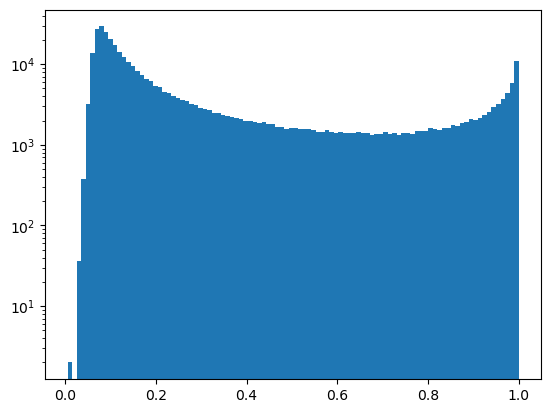

In [6]:
plt.hist(anno['am_pathogenicity'].drop_nulls(), bins=100, log=True)
plt.show()

In [7]:
selected_annos = anno_config_df.filter(
    # (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation', 'splicing'])) # CDS
    # pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation', 'regulatory_nondir']) # missense
    # pl.col('category').is_in(['genetic_diversity', 'conservation', 'splicing']) # 'splicing'

    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir'])) # non coding
    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])) # introns
    (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense', 'gpn_star_llr_calibrated_mean', 'cadd_raw', 'pangolin_score', 'abexp_abs_max']))
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )

    .filter(
        # Remove null annotation scores
        (pl.col('annotation_score').is_not_null())
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr3:191250077:A:G""","""ENSG00000188729""","""am_pathogenicity""",0.0474,"""missense""",1,397113.0
"""chr9:135907110:T:G""","""ENSG00000130559""","""am_pathogenicity""",0.1718,"""missense""",1,200038.0
"""chr9:135862595:C:T""","""ENSG00000130559""","""am_pathogenicity""",0.4524,"""missense""",1,108882.0
"""chr6:26468412:C:T""","""ENSG00000112763""","""am_pathogenicity""",0.1503,"""missense""",1,217679.0
"""chr9:135881637:T:C""","""ENSG00000130559""","""am_pathogenicity""",0.1888,"""missense""",1,188846.0
…,…,…,…,…,…,…
"""chr15:40703313:T:C""","""ENSG00000051180""","""abexp_abs_max""",0.004967,"""regulatory_nondir""",1,1.7786924e7
"""chr10:68568769:T:C""","""ENSG00000138336""","""abexp_abs_max""",0.005501,"""regulatory_nondir""",1,1.763904e7
"""chr4:44686285:G:A""","""ENSG00000163281""","""abexp_abs_max""",0.003182,"""regulatory_nondir""",1,1.880728e7


In [8]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

In [9]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

if pheno_list_type is not None:
    gene_trait_df = gene_trait_df.filter(pl.col('phenotype').is_in(pheno_list))

gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


## Odds ratio computation

In [10]:
n_steps = 101
min_rank_cutoff = 100
max_rank_cutoff = 10_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])
or_threshold_pheno = 0.99

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})

cutoffs_lazy.collect()

rank_cutoff
i64
100
112
125
141
158
…
6309573
7079457
7943282


In [11]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    # .select(["annotation", "region", "gene_name", "phenotype", "n_vars_above_ptile", "mean_pheno_value_dircor_ptile"])
    .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor_rank_desc", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "gene_name", "phenotype", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff', descending=True)

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,i64,u64,u64,u64,u64,f64
"""am_pathogenicity""","""ENSG00000155827""","""RNF20""","""mean_corpuscular_haemoglobin_i…",10000000,5,360,0,0,NaN
"""esmscoremissense""","""ENSG00000117400""","""MPL""","""platelet_count_int""",10000000,8,229,0,0,NaN
"""esmscoremissense""","""ENSG00000139044""","""B4GALNT3""","""alkaline_phosphatase_int""",10000000,2,435,0,0,NaN
"""esmscoremissense""","""ENSG00000138669""","""PRKG2""","""standing_height_int""",10000000,5,250,0,0,NaN
"""esmscoremissense""","""ENSG00000101191""","""DIDO1""","""arm_fat_mass_left_int""",10000000,14,1169,0,0,NaN
…,…,…,…,…,…,…,…,…,…
"""am_pathogenicity""","""ENSG00000135999""","""EPC2""","""forced_expiratory_volume_in_1s…",100,0,0,10,254,NaN
"""cadd_raw""","""ENSG00000196712""","""NF1""","""testosterone_int""",100,0,1,584,47929,0.0
"""esmscoremissense""","""ENSG00000107863""","""ARHGAP21""","""leg_predicted_mass_right_int""",100,0,0,5,817,NaN


## Plotting

In [12]:
# or_df.write_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_{or_threshold_pheno}_ranks_{min_rank_cutoff}_wgs_EUR_genebass1e6_maf1e3.parquet')
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

In [13]:
print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
        log_rank_cutoff = np.log10(pl.col('rank_cutoff')),
        log_rank_cutoff_inv = np.log10(1/pl.col('rank_cutoff')),
    )
    .with_columns(
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'log_rank_cutoff', 'rank_cutoff', 'log_rank_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .sort('log_rank_cutoff')
    
    # Remove data points without ci or with or=0
    .filter(
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('n_gene_phenos') >= 10) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""gpn_star_llr_calibrated_mean""",2.0,100,-2.0,124,0.0,2.78649,1.293112,5.320989,0.25199,"""#942c80""","""GPN-Star""","""conservation"""
"""gpn_star_llr_calibrated_mean""",2.049218,112,-2.049218,127,0.0,4.583961,1.593831,7.70787,1.460052,"""#942c80""","""GPN-Star""","""conservation"""
"""gpn_star_llr_calibrated_mean""",2.09691,125,-2.09691,132,0.0,4.410326,1.535133,7.419188,1.401465,"""#942c80""","""GPN-Star""","""conservation"""
"""gpn_star_llr_calibrated_mean""",2.149219,141,-2.149219,135,0.0,5.803865,1.718405,9.171939,2.435791,"""#942c80""","""GPN-Star""","""conservation"""
"""abexp_abs_max""",2.149219,141,-2.149219,68,0.0,9.837521,3.89746,17.476542,2.1985,"""#80CBC4""","""AbExp abs max""","""regulatory_nondir"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""pangolin_score""",6.95,8912509,-6.95,1161,1.090433,1.226174,0.024064,1.273339,1.179008,"""#2E7D32""","""Pangolin""","""splicing"""
"""gpn_star_llr_calibrated_mean""",7.0,10000000,-7.0,1145,1.090166,1.227367,0.018309,1.263252,1.191482,"""#942c80""","""GPN-Star""","""conservation"""
"""cadd_raw""",7.0,10000000,-7.0,1159,1.106389,1.313869,0.030043,1.372754,1.254984,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


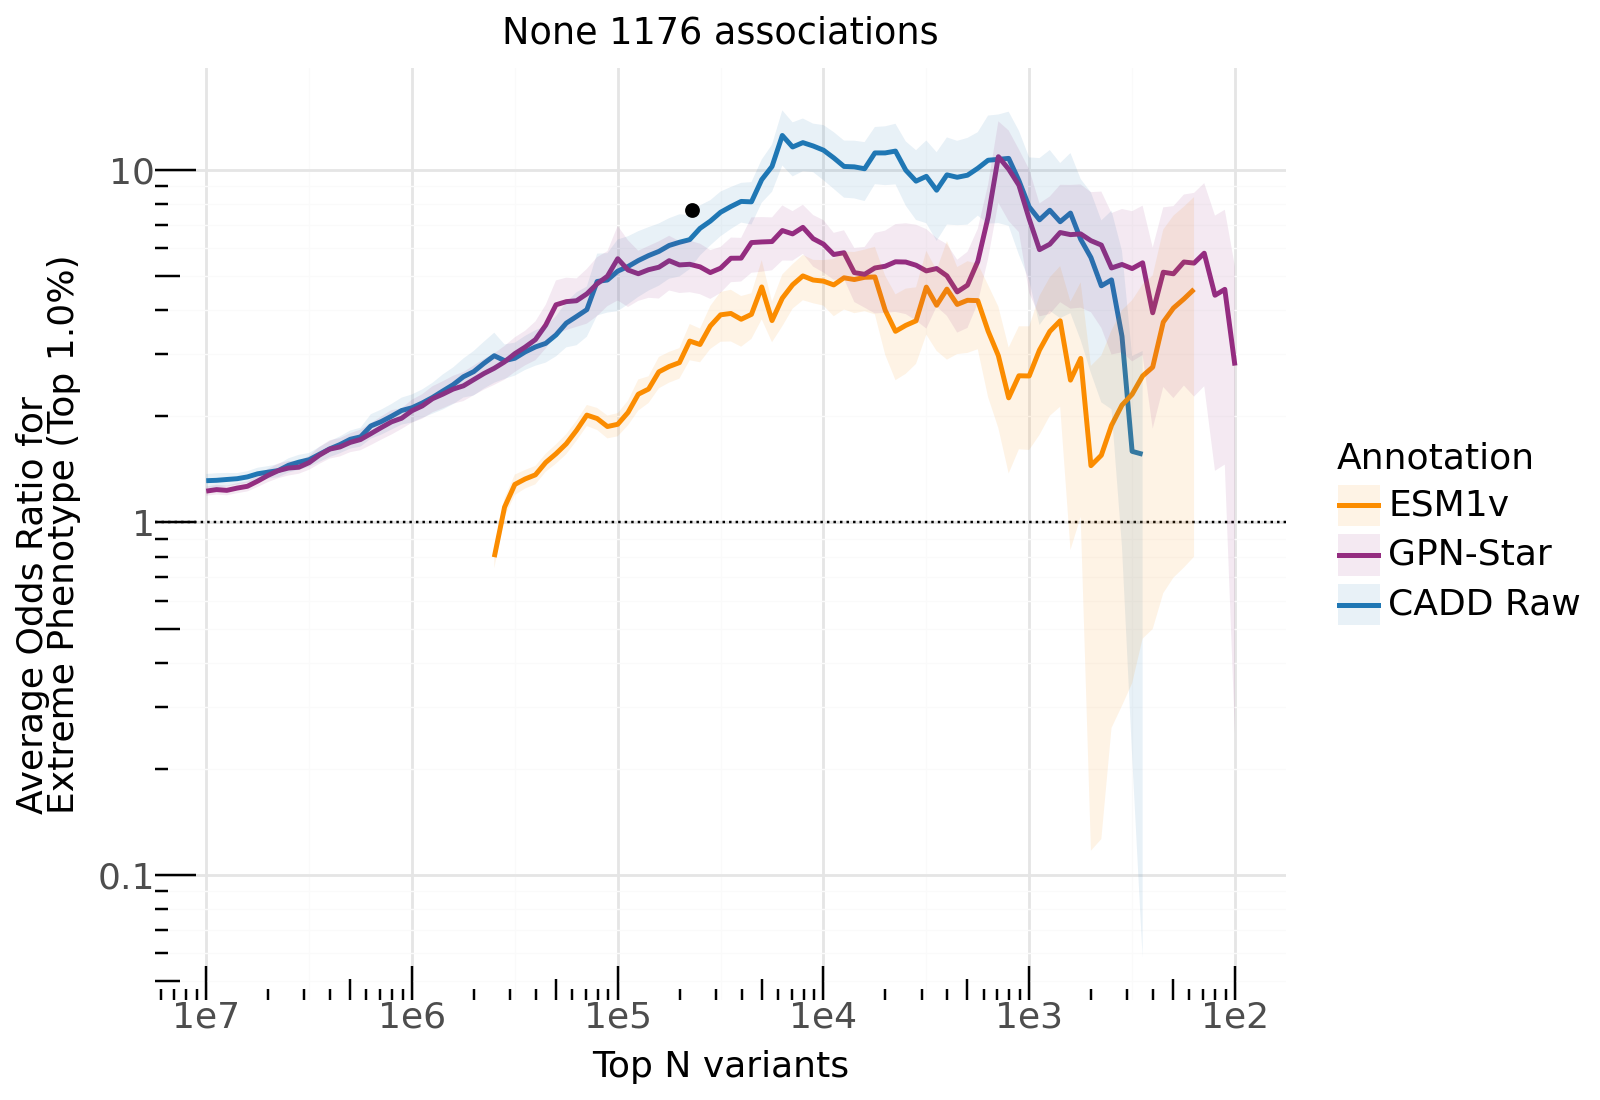

In [16]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') <= -4) &

        # (pl.col('annotation').is_in(['am_pathogenicity', 'score_pai3d', 'esmscoremissense', 'gpn_star_llr_calibrated_mean']))
        (pl.col('annotation').is_in(['esmscoremissense', 'gpn_star_llr_calibrated_mean', 'cadd_raw']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_star_llr_calibrated_mean', 'cadd_raw', 'abexp_abs_max', 'pangolin_score']))
        # (pl.col('annotation').is_in(['gpn_star_llr_calibrated_mean', 'pangolin_score', 'abexp_abs_max']))
        # (pl.col('annotation').is_in(['gpn_star_llr_calibrated_mean', 'cadd_raw', 'abexp_abs_max', 'promoterai_abs', 'max_fz_blood']))
        # (pl.col('category').is_in(['missense', 'genetic_diversity']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

# Determine legend order based on final average odds ratio
legend_order = (
    plot_df.sort("log_rank_cutoff_inv")
    .group_by("label", maintain_order=True)
    .last()
    .sort("avg_odds_ratio", descending=True)
    ['label']
    .to_list()
)

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)

loftee_or = pl.DataFrame({
    'region': ['gene_body_5kb', 'gene_body', 'cds'],
    'n_vars': [-np.log10(43_640), -np.log10(43_640), -np.log10(43_640)],
    'mean_or': [13.392815, 11.88451, 7.703493],
})

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + geom_point(loftee_or.filter(pl.col('region')=='cds'), aes(x='n_vars', y='mean_or'), color='black', size=2)
    + scale_fill_manual(values=color_dict, limits=legend_order)
    + scale_color_manual(values=color_dict, limits=legend_order)
    + labs(
        title=f"{pheno_list_type} {or_df[['gene_name', 'phenotype']].unique().shape[0]} associations",
        y=f"Average Odds Ratio for\nExtreme Phenotype (Top {pheno_label}%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(8, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [15]:
plt_df.head()

annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""gpn_star_llr_calibrated_mean""",2.0,100,-2.0,124,0.0,2.78649,1.293112,5.320989,0.25199,"""#942c80""","""GPN-Star""","""conservation"""
"""gpn_star_llr_calibrated_mean""",2.049218,112,-2.049218,127,0.0,4.583961,1.593831,7.70787,1.460052,"""#942c80""","""GPN-Star""","""conservation"""
"""gpn_star_llr_calibrated_mean""",2.09691,125,-2.09691,132,0.0,4.410326,1.535133,7.419188,1.401465,"""#942c80""","""GPN-Star""","""conservation"""
"""gpn_star_llr_calibrated_mean""",2.149219,141,-2.149219,135,0.0,5.803865,1.718405,9.171939,2.435791,"""#942c80""","""GPN-Star""","""conservation"""
"""abexp_abs_max""",2.149219,141,-2.149219,68,0.0,9.837521,3.89746,17.476542,2.1985,"""#80CBC4""","""AbExp abs max""","""regulatory_nondir"""
